# Parallel REINFORCE + GAE + Adaptive Baseline on PyBullet (Colab)

Goal: end-to-end study of REINFORCE with a learned baseline and GAE on vectorized PyBullet environments.

- Parallel rollout collection via `AsyncVectorEnv/SyncVectorEnv`
- Full reproducibility: fixed seeds, library versions, and device info
- Logging and artifacts saved to `/content/runs/<timestamp>/`


## 2) Setup & Install

In [1]:

import sys, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable,'-m','pip','install','-q',*pkgs])

primary=[
    'numpy>=1.24','pandas>=2.0','matplotlib>=3.7','tqdm>=4.65','psutil>=5.9',
    'gymnasium>=0.29,<1.1','pybullet>=3.2.6','pybullet-envs-gymnasium>=0.6.0','torch>=2.1'
]
fallback=[
    'numpy>=1.24','pandas>=2.0','matplotlib>=3.7','tqdm>=4.65','psutil>=5.9',
    'gymnasium>=0.29,<1.1','pybullet>=3.2.6','pybullet_envs_gymnasium>=0.6.0','torch>=2.1'
]
try:
    pip_install(primary)
except Exception as e:
    print('Primary failed:',repr(e))
    pip_install(fallback)
print('Install done')


Install done


In [2]:

import os, json, time, random, platform
from dataclasses import dataclass, asdict, replace
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
import numpy as np, pandas as pd, matplotlib.pyplot as plt, psutil
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym

try:
    import pybullet_envs_gymnasium  # noqa: F401
    PYB='pybullet_envs_gymnasium'
except Exception as e:
    PYB=f'registration_failed: {repr(e)}'
print('PyBullet backend:',PYB)


PyBullet backend: pybullet_envs_gymnasium


## 3) Reproducibility

In [3]:

def set_seed(seed:int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

GLOBAL_SEED=42
set_seed(GLOBAL_SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'

sys_info={
    'python':sys.version,'platform':platform.platform(),'cpu_logical':psutil.cpu_count(True),
    'cpu_physical':psutil.cpu_count(False),'ram_gb':round(psutil.virtual_memory().total/1024**3,2),
    'torch':torch.__version__,'gymnasium':gym.__version__,'numpy':np.__version__,'pandas':pd.__version__,
    'matplotlib':plt.matplotlib.__version__,'device':DEVICE,
    'cuda_name':torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
print(json.dumps(sys_info,indent=2,ensure_ascii=False))


{
  "python": "3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]",
  "platform": "Linux-6.6.105+-x86_64-with-glibc2.35",
  "cpu_logical": 2,
  "cpu_physical": 1,
  "ram_gb": 12.67,
  "torch": "2.9.0+cu128",
  "gymnasium": "1.0.0",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "matplotlib": "3.10.0",
  "device": "cuda",
  "cuda_name": "Tesla T4"
}


## 4) Environment

In [4]:

CANDIDATE_ENVS=['HopperBulletEnv-v0','Walker2DBulletEnv-v0','HalfCheetahBulletEnv-v0','AntBulletEnv-v0']

def env_available(env_id:str)->bool:
    try:
        e=gym.make(env_id); _=e.reset(seed=GLOBAL_SEED); e.close(); return True
    except Exception as ex:
        print(env_id,'unavailable:',repr(ex)); return False

selected_env=next((e for e in CANDIDATE_ENVS if env_available(e)),None)
if selected_env is None:
    raise RuntimeError('No target PyBullet env available. Reinstall pybullet-envs-gymnasium and restart runtime.')

print('Selected env:',selected_env)
demo=gym.make(selected_env)
obs,_=demo.reset(seed=GLOBAL_SEED)
print('Obs space:',demo.observation_space)
print('Act space:',demo.action_space)
print('Obs shape:',obs.shape,'Act shape:',demo.action_space.shape)
demo.close()


Selected env: HopperBulletEnv-v0
Obs space: Box(-inf, inf, (15,), float32)
Act space: Box(-1.0, 1.0, (3,), float32)
Obs shape: (15,) Act shape: (3,)


### Environment Notes

- PyBullet locomotion tasks use continuous action spaces and vector observations.
- Reward typically combines forward progress with control regularization and stability terms.
- An episode ends on failure conditions or time limits.
- `done` masking is applied in returns/advantages to prevent bootstrap leakage across episodes.


## 5) Algorithm Overview

REINFORCE:
\[
\nabla_\theta J(\theta)=\mathbb{E}[\nabla_\theta\log\pi_\theta(a_t|s_t)A_t]
\]

Baseline (value): \(A_t \approx G_t - V_\phi(s_t)\)

GAE:
\[
\delta_t=r_t+\gamma V(s_{t+1})-V(s_t),\;
A_t^{GAE}=\sum_{l\ge 0}(\gamma\lambda)^l\delta_{t+l}
\]

Losses:
- policy: `-E[log_prob * advantage]`
- value: `MSE(V, returns)`
- entropy bonus (optional)


## 6) Implementation

### 6.1 Utils (seeding, running mean/std, logging)

In [5]:

@dataclass
class Config:
    env_name:str; num_envs:int; rollout_len:int; gamma:float; gae_lambda:float
    lr_policy:float; lr_value:float; value_coef:float; entropy_coef:float; max_grad_norm:float
    total_iterations:int; eval_every:int; eval_episodes:int; seed:int; normalize_advantage:bool; device:str
    use_baseline:bool=True; async_vector_env:bool=True; hidden_sizes:Tuple[int,int]=(128,128)
    max_env_steps:int=600_000; solved_return:Optional[float]=None; normalize_observation:bool=True
    obs_clip:float=10.0; eval_max_steps:int=2000; experiment_name:str='default'
    value_update_epochs:int=4; scale_value_loss_by_return_std:bool=True

class RunningMeanStd:
    def __init__(self,shape,eps=1e-4):
        self.mean=np.zeros(shape,np.float64); self.var=np.ones(shape,np.float64); self.count=eps
    def update(self,x):
        x=np.asarray(x,np.float64); x=x[None,:] if x.ndim==1 else x
        bm,bv,bc=x.mean(0),x.var(0),x.shape[0]; d=bm-self.mean; tc=self.count+bc
        new_mean=self.mean+d*bc/tc; ma=self.var*self.count; mb=bv*bc; m2=ma+mb+(d**2)*self.count*bc/tc
        self.mean,self.var,self.count=new_mean,np.maximum(m2/tc,1e-12),tc
    def normalize(self,x,clip=10.0):
        x=(x-self.mean)/(np.sqrt(self.var)+1e-8); return np.clip(x,-clip,clip)

class Logger:
    def __init__(self,run_dir:Path,cfg:Config):
        self.run_dir=Path(run_dir); self.run_dir.mkdir(parents=True,exist_ok=True); self.rows=[]
        (self.run_dir/'config.json').write_text(json.dumps(asdict(cfg),indent=2,ensure_ascii=False),encoding='utf-8')
    def log(self,row:Dict[str,Any]): self.rows.append(row)
    def flush(self)->pd.DataFrame:
        df=pd.DataFrame(self.rows); df.to_csv(self.run_dir/'metrics.csv',index=False)
        (self.run_dir/'metrics.json').write_text(json.dumps(self.rows,indent=2,ensure_ascii=False),encoding='utf-8')
        return df


### 6.2 Vectorized env factory

In [6]:

def make_env_thunk(env_name:str,seed:int,idx:int):
    def _thunk():
        env=gym.make(env_name); env=gym.wrappers.RecordEpisodeStatistics(env)
        env.reset(seed=seed+idx); env.action_space.seed(seed+idx); return env
    return _thunk

def make_vec_env(env_name:str,num_envs:int,seed:int,async_mode=True):
    thunks=[make_env_thunk(env_name,seed,i) for i in range(num_envs)]
    if num_envs==1: return gym.vector.SyncVectorEnv(thunks)
    if async_mode:
        try: return gym.vector.AsyncVectorEnv(thunks)
        except Exception as e:
            print('AsyncVectorEnv failed, fallback Sync:',repr(e))
    return gym.vector.SyncVectorEnv(thunks)


### 6.3 Networks

In [7]:

class MLP(nn.Module):
    def __init__(self,in_dim,hidden,out_dim):
        super().__init__(); h1,h2=hidden
        self.net=nn.Sequential(nn.Linear(in_dim,h1),nn.Tanh(),nn.Linear(h1,h2),nn.Tanh(),nn.Linear(h2,out_dim))
    def forward(self,x): return self.net(x)

class GaussianPolicy(nn.Module):
    LOG_STD_MIN,LOG_STD_MAX=-5.0,2.0
    def __init__(self,obs_dim,act_dim,hidden):
        super().__init__(); self.mean_net=MLP(obs_dim,hidden,act_dim); self.log_std=nn.Parameter(torch.zeros(act_dim))
    def _dist(self,obs):
        mean=self.mean_net(obs); log_std=torch.clamp(self.log_std,self.LOG_STD_MIN,self.LOG_STD_MAX)
        std=log_std.exp().expand_as(mean); return torch.distributions.Normal(mean,std)
    def sample(self,obs):
        d=self._dist(obs); a=d.rsample(); lp=d.log_prob(a)
        assert lp.ndim==2,f'Expected [B,act_dim], got {lp.shape}'
        return a,lp.sum(-1),d.entropy().sum(-1)
    def log_prob(self,obs,a):
        lp=self._dist(obs).log_prob(a); assert lp.ndim==2,f'Expected [B,act_dim], got {lp.shape}'; return lp.sum(-1)
    def entropy(self,obs): return self._dist(obs).entropy().sum(-1)
    def act_det(self,obs): return self.mean_net(obs)

class ValueNet(nn.Module):
    def __init__(self,obs_dim,hidden): super().__init__(); self.v=MLP(obs_dim,hidden,1)
    def forward(self,obs): return self.v(obs).squeeze(-1)


### 6.4 Rollout collection

In [8]:

def to_tensor(x,device): return torch.as_tensor(x,dtype=torch.float32,device=device)

def collect_rollout(vec_env,policy,value_net,obs,cfg,obs_rms,ep_ret,ep_len):
    T,N=cfg.rollout_len,cfg.num_envs
    obs_buf=np.zeros((T,N)+obs.shape[1:],np.float32)
    act_buf=np.zeros((T,N)+vec_env.single_action_space.shape,np.float32)
    rew_buf=np.zeros((T,N),np.float32); done_buf=np.zeros((T,N),np.float32)
    logp_buf=np.zeros((T,N),np.float32); val_buf=np.zeros((T,N),np.float32)
    done_returns,done_lengths=[],[]
    lo,hi=vec_env.single_action_space.low,vec_env.single_action_space.high

    for t in range(T):
        if obs_rms is not None:
            obs_rms.update(obs)
            obs_in=obs_rms.normalize(obs,cfg.obs_clip)
        else:
            obs_in=obs
        obs_t=to_tensor(obs_in,cfg.device)
        with torch.no_grad():
            a_t,lp_t,_=policy.sample(obs_t)
            v_t=value_net(obs_t) if cfg.use_baseline else torch.zeros(cfg.num_envs,device=cfg.device)
        a_np=np.clip(a_t.cpu().numpy(),lo,hi)
        next_obs,r,term,trunc,info=vec_env.step(a_np)
        d=np.logical_or(term,trunc)

        obs_buf[t]=obs; act_buf[t]=a_np; rew_buf[t]=r; done_buf[t]=d.astype(np.float32)
        logp_buf[t]=lp_t.cpu().numpy(); val_buf[t]=v_t.cpu().numpy()

        ep_ret+=r; ep_len+=1
        for i in np.where(d)[0]:
            done_returns.append(float(ep_ret[i])); done_lengths.append(int(ep_len[i]))
            ep_ret[i]=0.0; ep_len[i]=0
        obs=next_obs

    obs_in=obs_rms.normalize(obs,cfg.obs_clip) if obs_rms is not None else obs
    with torch.no_grad():
        next_v=value_net(to_tensor(obs_in,cfg.device)).cpu().numpy() if cfg.use_baseline else np.zeros(cfg.num_envs,np.float32)

    return dict(obs=obs_buf,actions=act_buf,rewards=rew_buf,dones=done_buf,log_probs=logp_buf,values=val_buf,
                next_value=next_v.astype(np.float32),next_obs=obs,done_returns=done_returns,done_lengths=done_lengths,
                ep_ret=ep_ret,ep_len=ep_len)

def evaluate(env_name,policy,cfg,obs_rms,episodes):
    env=gym.make(env_name); rets=[]
    for ep in range(episodes):
        obs,_=env.reset(seed=cfg.seed+10000+ep); done=False; trunc=False; total=0.0; steps=0
        while not (done or trunc):
            obs_in=obs_rms.normalize(obs[None,:],cfg.obs_clip)[0] if obs_rms is not None else obs
            with torch.no_grad(): a=policy.act_det(to_tensor(obs_in[None,:],cfg.device)).cpu().numpy()[0]
            a=np.clip(a,env.action_space.low,env.action_space.high)
            obs,r,done,trunc,_=env.step(a); total+=float(r); steps+=1
            if steps>=cfg.eval_max_steps: break
        rets.append(total)
    env.close(); return float(np.mean(rets)),float(np.std(rets)),rets


### 6.5 Advantage & Returns + checks

In [9]:

def compute_returns_adv(rewards,dones,values,next_value,gamma,gae_lambda,use_baseline):
    T,N=rewards.shape
    assert dones.shape==(T,N) and values.shape==(T,N) and next_value.shape==(N,)
    returns=np.zeros((T,N),np.float32); run=next_value.copy().astype(np.float32)
    for t in reversed(range(T)):
        nt=1.0-dones[t]; run=rewards[t]+gamma*run*nt; returns[t]=run

    if use_baseline:
        adv=np.zeros((T,N),np.float32); last=np.zeros(N,np.float32)
        for t in reversed(range(T)):
            nv=next_value if t==T-1 else values[t+1]
            nt=1.0-dones[t]; delta=rewards[t]+gamma*nv*nt-values[t]
            last=delta+gamma*gae_lambda*nt*last; adv[t]=last
    else:
        adv=returns.copy()

    assert np.isfinite(returns).all() and np.isfinite(adv).all()
    return returns,adv

# Unit checks
Tt,Nt=4,3
r=np.random.randn(Tt,Nt).astype(np.float32); d=np.zeros((Tt,Nt),np.float32)
v=np.random.randn(Tt,Nt).astype(np.float32); nv=np.random.randn(Nt).astype(np.float32)
ret,adv=compute_returns_adv(r,d,v,nv,0.99,0.95,True)
assert ret.shape==(Tt,Nt) and adv.shape==(Tt,Nt)

r=np.array([[1.0],[1.0],[1.0]],np.float32); d=np.array([[0.0],[1.0],[0.0]],np.float32)
v=np.zeros((3,1),np.float32); nv=np.array([10.0],np.float32)
ret,adv=compute_returns_adv(r,d,v,nv,1.0,1.0,False)
assert np.allclose(ret[:,0],np.array([2.0,1.0,11.0],np.float32)),ret[:,0]
print('Unit checks passed')


Unit checks passed


### 6.6 Losses & Update

In [10]:

def update_step(policy,value_net,policy_opt,value_opt,obs,actions,returns,adv,cfg):
    assert obs.ndim==2 and actions.ndim==2 and returns.ndim==1 and adv.ndim==1
    assert obs.shape[0]==actions.shape[0]==returns.shape[0]==adv.shape[0]

    if cfg.normalize_advantage:
        adv=(adv-adv.mean())/adv.std(unbiased=False).clamp_min(1e-8)

    # Policy update: single on-policy step
    policy_opt.zero_grad(set_to_none=True)
    lp=policy.log_prob(obs,actions); ent=policy.entropy(obs).mean()
    pol_loss=-(lp*adv.detach()).mean(); (pol_loss-cfg.entropy_coef*ent).backward()
    if cfg.max_grad_norm and cfg.max_grad_norm>0: nn.utils.clip_grad_norm_(policy.parameters(),cfg.max_grad_norm)
    policy_opt.step()

    # Value update: multiple epochs on same rollout batch to stabilize baseline
    if cfg.use_baseline:
        v_losses=[]
        ret_std=returns.std(unbiased=False).clamp_min(1e-3)
        for _ in range(max(1,int(cfg.value_update_epochs))):
            value_opt.zero_grad(set_to_none=True)
            vpred=value_net(obs)
            verr=vpred-returns
            if cfg.scale_value_loss_by_return_std:
                verr=verr/ret_std
            v_loss=(verr**2).mean()
            (cfg.value_coef*v_loss).backward()
            if cfg.max_grad_norm and cfg.max_grad_norm>0: nn.utils.clip_grad_norm_(value_net.parameters(),cfg.max_grad_norm)
            value_opt.step()
            v_losses.append(v_loss.detach())
        v_loss=torch.stack(v_losses).mean()
    else:
        v_loss=torch.tensor(0.0,device=obs.device)

    return {'policy_loss':float(pol_loss.detach().cpu()),'value_loss':float(v_loss.detach().cpu()),'entropy':float(ent.detach().cpu())}


### 6.7 Training loop

In [11]:

def autotune(cfg:Config)->Config:
    c=replace(cfg); c.max_env_steps=int(np.clip(c.max_env_steps,100_000,2_000_000))
    if 'Ant' in c.env_name: c.num_envs=min(c.num_envs,8); c.rollout_len=min(c.rollout_len,128)
    if c.device=='cpu': c.num_envs=min(c.num_envs,8)
    return c

def train_one(cfg:Config,run_dir:Path):
    cfg=autotune(cfg); set_seed(cfg.seed); logger=Logger(run_dir,cfg)
    vec=make_vec_env(cfg.env_name,cfg.num_envs,cfg.seed,cfg.async_vector_env); obs,_=vec.reset(seed=cfg.seed)
    obs_dim=int(np.prod(vec.single_observation_space.shape)); act_dim=int(np.prod(vec.single_action_space.shape))
    policy=GaussianPolicy(obs_dim,act_dim,cfg.hidden_sizes).to(cfg.device)
    value=ValueNet(obs_dim,cfg.hidden_sizes).to(cfg.device)
    po=optim.Adam(policy.parameters(),lr=cfg.lr_policy); vo=optim.Adam(value.parameters(),lr=cfg.lr_value)
    obs_rms=RunningMeanStd(vec.single_observation_space.shape) if cfg.normalize_observation else None
    ep_ret=np.zeros(cfg.num_envs,np.float32); ep_len=np.zeros(cfg.num_envs,np.int32)
    steps=0; best_eval=-np.inf; solved=None; t0=time.perf_counter()

    pbar=tqdm(range(1,cfg.total_iterations+1),desc=f'Train {cfg.experiment_name}')
    for it in pbar:
        tr0=time.perf_counter()
        roll=collect_rollout(vec,policy,value,obs,cfg,obs_rms,ep_ret,ep_len)
        tr1=time.perf_counter(); obs=roll['next_obs']; ep_ret=roll['ep_ret']; ep_len=roll['ep_len']

        rewards,dones,values,nv=roll['rewards'],roll['dones'],roll['values'],roll['next_value']
        returns,adv=compute_returns_adv(rewards,dones,values,nv,cfg.gamma,cfg.gae_lambda,cfg.use_baseline)
        T,N=rewards.shape
        ob=roll['obs'].reshape(T*N,-1); ac=roll['actions'].reshape(T*N,-1)
        re=returns.reshape(T*N); ad=adv.reshape(T*N)
        assert ob.shape[0]==ac.shape[0]==re.shape[0]==ad.shape[0]==T*N
        if obs_rms is not None: ob=obs_rms.normalize(ob,cfg.obs_clip)

        up0=time.perf_counter()
        st=update_step(policy,value,po,vo,to_tensor(ob,cfg.device),to_tensor(ac,cfg.device),to_tensor(re,cfg.device),to_tensor(ad,cfg.device),cfg)
        up1=time.perf_counter()

        it_steps=cfg.rollout_len*cfg.num_envs; steps+=it_steps; rt=tr1-tr0; ut=up1-up0
        row=dict(iteration=it,global_env_steps=steps,policy_loss=st['policy_loss'],value_loss=st['value_loss'],entropy=st['entropy'],
                 adv_mean=float(np.mean(adv)),adv_std=float(np.std(adv)),adv_max=float(np.max(adv)),
                 train_episode_return_mean=float(np.mean(roll['done_returns'])) if roll['done_returns'] else np.nan,
                 train_episode_len_mean=float(np.mean(roll['done_lengths'])) if roll['done_lengths'] else np.nan,
                 rollout_time_sec=rt,update_time_sec=ut,iter_time_sec=up1-tr0,steps_per_sec=it_steps/max(rt,1e-8),
                 eval_return_mean=np.nan,eval_return_std=np.nan)

        if it%cfg.eval_every==0:
            em,es,_=evaluate(cfg.env_name,policy,cfg,obs_rms,cfg.eval_episodes)
            row['eval_return_mean']=em; row['eval_return_std']=es; best_eval=max(best_eval,em)
            if cfg.solved_return is not None and solved is None and em>=cfg.solved_return: solved=it

        logger.log(row)
        pbar.set_postfix({'eval':f"{row['eval_return_mean']:.1f}" if np.isfinite(row['eval_return_mean']) else '-',
                          'fps':f"{row['steps_per_sec']:.0f}",'pl':f"{row['policy_loss']:.3f}"})
        if steps>=cfg.max_env_steps:
            print('Stop by max_env_steps=',cfg.max_env_steps); break

    pbar.close(); hist=logger.flush(); total=time.perf_counter()-t0
    fem,fes,_=evaluate(cfg.env_name,policy,cfg,obs_rms,cfg.eval_episodes)
    summary=dict(experiment_name=cfg.experiment_name,env_name=cfg.env_name,seed=cfg.seed,use_baseline=cfg.use_baseline,
                 gae_lambda=cfg.gae_lambda,num_envs=cfg.num_envs,normalize_advantage=cfg.normalize_advantage,
                 final_eval_return_mean=fem,final_eval_return_std=fes,best_eval_return=float(best_eval) if np.isfinite(best_eval) else np.nan,
                 time_to_threshold_iter=solved,mean_steps_per_sec=float(hist['steps_per_sec'].mean()),
                 mean_rollout_time_sec=float(hist['rollout_time_sec'].mean()),mean_update_time_sec=float(hist['update_time_sec'].mean()),
                 total_wall_time_sec=float(total),total_env_steps=int(hist['global_env_steps'].max()),run_dir=str(run_dir))
    (Path(run_dir)/'summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding='utf-8')
    vec.close(); return hist,summary


## 7) Experiments

### 7.1 Base run, 7.2 Ablations, 7.3 Efficiency

Notes:
- Use `PROFILE` in the next cell to control runtime budget (`quick` / `balanced` / `full`).
- `abl_num_envs_{1,4,8}` uses the same `max_env_steps` for a fair sample-efficiency comparison.
- Base seeds use a larger budget than ablations.


In [12]:

RUN_TS=datetime.now().strftime('%Y%m%d_%H%M%S')
ROOT_RUN_DIR=Path('/content/runs')/RUN_TS
ROOT_RUN_DIR.mkdir(parents=True,exist_ok=True)
print('ROOT_RUN_DIR:',ROOT_RUN_DIR)

SOLVED={'HopperBulletEnv-v0':2500.0,'Walker2DBulletEnv-v0':2200.0,'HalfCheetahBulletEnv-v0':3000.0,'AntBulletEnv-v0':2500.0}

# Profiles for Colab cost/quality trade-off
# quick: fast smoke test, balanced: recommended, full: deeper training
PROFILE='balanced'  # change to 'quick' or 'full' if needed
PROFILE_BUDGETS={
    'quick':    dict(base_steps=200_000, ablation_steps=100_000, efficiency_steps=80_000, eval_episodes=5),
    'balanced': dict(base_steps=500_000, ablation_steps=250_000, efficiency_steps=120_000, eval_episodes=7),
    'full':     dict(base_steps=1_000_000, ablation_steps=500_000, efficiency_steps=250_000, eval_episodes=10),
}
B=PROFILE_BUDGETS[PROFILE]

base=Config(env_name=selected_env,num_envs=8,rollout_len=128,gamma=0.99,gae_lambda=0.95,
            lr_policy=3e-4,lr_value=3e-4,value_coef=0.5,entropy_coef=1e-3,max_grad_norm=0.5,
            total_iterations=1000,eval_every=10,eval_episodes=B['eval_episodes'],seed=42,normalize_advantage=True,device=DEVICE,
            use_baseline=True,async_vector_env=True,hidden_sizes=(128,128),max_env_steps=B['base_steps'],
            solved_return=SOLVED.get(selected_env,None),normalize_observation=True,experiment_name='base',
            value_update_epochs=4,scale_value_loss_by_return_std=True)

def set_budget(c:Config,target_steps:int)->Config:
    iters=int(np.ceil(target_steps/(c.rollout_len*c.num_envs)))+2
    return replace(c,total_iterations=iters,max_env_steps=int(target_steps))

cfgs=[]
# Base stability: 3 seeds with larger budget
for s in [11,22,33]:
    cfgs.append(set_budget(replace(base,seed=s,experiment_name=f'base_seed_{s}'),B['base_steps']))

# A) no baseline vs baseline
cfgs.append(set_budget(replace(base,seed=44,use_baseline=False,gae_lambda=1.0,experiment_name='abl_no_baseline'),B['ablation_steps']))

# B) lambda sweep
for lam in [1.0,0.9,0.97]:
    cfgs.append(set_budget(replace(base,seed=55,gae_lambda=lam,experiment_name=f'abl_lambda_{lam}'),B['ablation_steps']))

# C) num_envs sweep with equal total_env_steps (fair sample-efficiency comparison)
for n in [1,4,8]:
    cfgs.append(set_budget(replace(base,seed=66,num_envs=n,experiment_name=f'abl_num_envs_{n}'),B['efficiency_steps']))

# D) advantage normalization off
cfgs.append(set_budget(replace(base,seed=77,normalize_advantage=False,experiment_name='abl_advnorm_off'),B['ablation_steps']))

print('Profile:',PROFILE)
print('Planned runs:',len(cfgs))
for c in cfgs:
    print(f"- {c.experiment_name}: seed={c.seed}, N={c.num_envs}, lambda={c.gae_lambda}, baseline={c.use_baseline}, advnorm={c.normalize_advantage}, target_steps={c.max_env_steps}, iters={c.total_iterations}")


ROOT_RUN_DIR: /content/runs/20260212_200221
Profile: balanced
Planned runs: 11
- base_seed_11: seed=11, N=8, lambda=0.95, baseline=True, advnorm=True, target_steps=500000, iters=491
- base_seed_22: seed=22, N=8, lambda=0.95, baseline=True, advnorm=True, target_steps=500000, iters=491
- base_seed_33: seed=33, N=8, lambda=0.95, baseline=True, advnorm=True, target_steps=500000, iters=491
- abl_no_baseline: seed=44, N=8, lambda=1.0, baseline=False, advnorm=True, target_steps=250000, iters=247
- abl_lambda_1.0: seed=55, N=8, lambda=1.0, baseline=True, advnorm=True, target_steps=250000, iters=247
- abl_lambda_0.9: seed=55, N=8, lambda=0.9, baseline=True, advnorm=True, target_steps=250000, iters=247
- abl_lambda_0.97: seed=55, N=8, lambda=0.97, baseline=True, advnorm=True, target_steps=250000, iters=247
- abl_num_envs_1: seed=66, N=1, lambda=0.95, baseline=True, advnorm=True, target_steps=120000, iters=940
- abl_num_envs_4: seed=66, N=4, lambda=0.95, baseline=True, advnorm=True, target_steps=

In [13]:

all_histories={}; all_summaries=[]
for cfg in cfgs:
    rd=ROOT_RUN_DIR/cfg.experiment_name
    print("\n"+"="*88)
    print('Running:',cfg.experiment_name)
    try:
        h,s=train_one(cfg,rd)
        all_histories[cfg.experiment_name]=h
        all_summaries.append(s)
        print(f"Done: {cfg.experiment_name} | final_eval={s['final_eval_return_mean']:.2f}")
    except Exception as e:
        print(f"FAILED: {cfg.experiment_name} -> {repr(e)}")

results_df=pd.DataFrame(all_summaries).sort_values('experiment_name').reset_index(drop=True)
results_df.to_csv(ROOT_RUN_DIR/'results_table.csv',index=False)
results_df.to_json(ROOT_RUN_DIR/'results_table.json',orient='records',indent=2,force_ascii=False)
print('Saved:',ROOT_RUN_DIR/'results_table.csv',ROOT_RUN_DIR/'results_table.json')
display(results_df.head(20))



Running: base_seed_11


Train base_seed_11:   0%|          | 0/491 [00:00<?, ?it/s]

Stop by max_env_steps= 500000
Done: base_seed_11 | final_eval=37.49

Running: base_seed_22


Train base_seed_22:   0%|          | 0/491 [00:00<?, ?it/s]

Stop by max_env_steps= 500000
Done: base_seed_22 | final_eval=16.12

Running: base_seed_33


...

Train abl_num_envs_8:   0%|          | 0/120 [00:00<?, ?it/s]

Stop by max_env_steps= 120000
Done: abl_num_envs_8 | final_eval=16.26

Running: abl_advnorm_off


Train abl_advnorm_off:   0%|          | 0/247 [00:00<?, ?it/s]

Stop by max_env_steps= 250000
Done: abl_advnorm_off | final_eval=761.29
Saved: /content/runs/20260212_200221/results_table.csv /content/runs/20260212_200221/results_table.json


,experiment_name,env_name,seed,use_baseline,gae_lambda,num_envs,normalize_advantage,final_eval_return_mean,final_eval_return_std,best_eval_return,time_to_threshold_iter,mean_steps_per_sec,mean_rollout_time_sec,mean_update_time_sec,total_wall_time_sec,total_env_steps,run_dir
0,abl_advnorm_off,HopperBulletEnv-v0,77,True,0.95,8,False,761.289806,11.102022,805.731023,None,1335.624319,0.785239,0.012366,281.989179,250880,/content/runs/20260212_200221/abl_advnorm_off
1,abl_lambda_0.9,HopperBulletEnv-v0,55,True,0.90,8,True,16.003766,0.344844,22.148425,None,1370.581185,0.761796,0.012418,191.684037,250880,/content/runs/20260212_200221/abl_lambda_0.9
2,abl_lambda_0.97,HopperBulletEnv-v0,55,True,0.97,8,True,9.894288,4.517762,26.467647,None,1360.624307,0.767671,0.012742,193.424005,250880,/content/runs/20260212_200221/abl_lambda_0.97
3,abl_lambda_1.0,HopperBulletEnv-v0,55,True,1.00,8,True,10.144405,4.703122,65.742175,None,1374.268178,0.759330,0.012636,192.639796,250880,/content/runs/20260212_200221/abl_lambda_1.0
4,abl_no_baseline,HopperBulletEnv-v0,44,False,1.00,8,True,10.614066,8.119622,166.069383,None,1406.686764,0.742308,0.004607,187.500035,250880,/content/runs/20260212_200221/abl_no_baseline
5,abl_num_envs_1,HopperBulletEnv-v0,66,True,0.95,1,True,16.454218,0.558296,90.047191,None,529.255902,0.244128,0.012018,251.517670,120064,/content/runs/20260212_200221/abl_num_envs_1
6,abl_num_envs_4,HopperBulletEnv-v0,66,True,0.95,4,True,704.737878,78.331406,635.111590,None,1093.716125,0.475676,0.012442,142.286108,120320,/content/runs/20260212_200221/abl_num_envs_4
7,abl_num_envs_8,HopperBulletEnv-v0,66,True,0.95,8,True,16.262760,0.684610,54.080941,None,1320.984779,0.795600,0.012627,97.177136,120832,/content/runs/20260212_200221/abl_num_envs_8
8,base_seed_11,HopperBulletEnv-v0,11,True,0.95,8,True,37.488247,8.518037,38.738683,None,1363.419256,0.772585,0.014328,395.283835,500736,/content/runs/20260212_200221/base_seed_11
9,base_seed_22,HopperBulletEnv-v0,22,True,0.95,8,True,16.122155,1.015400,29.614457,None,1401.806376,0.744215,0.012560,374.423785,500736,/content/runs/20260212_200221/base_seed_22


1) Key outcomes
Training pipeline is functional end-to-end (all runs completed, logs/plots/tables saved).
Performance is highly variable across seeds in the base setup:
base_seed_11: 37.49
base_seed_22: 16.12
base_seed_33: -9.70
Base mean over 3 seeds: 14.64 ± 23.64 (high instability).
No run reached the environment “solved” threshold (time_to_threshold_iter = None for all).
2) Ablation highlights
Best final eval returns were:
abl_advnorm_off: 761.29 ± 11.10
abl_num_envs_4: 704.74 ± 78.33
Other ablations stayed low (mostly ~10–16):
abl_no_baseline: 10.61
abl_lambda_1.0: 10.14
abl_lambda_0.97: 9.89
abl_lambda_0.9: 16.00
abl_num_envs_1: 16.45
abl_num_envs_8: 16.26
3) Efficiency results
Throughput scales with parallelism:
N=1: ~529 steps/s
N=4: ~1094 steps/s
N=8: ~1321 steps/s
Wall-clock for equal-step efficiency runs:
N=1: ~251.5 s
N=4: ~142.3 s
N=8: ~97.2 s
N=8 is ~2.5x faster than N=1 in FPS.
4) Interpretation
The notebook successfully demonstrates parallel on-policy training and experiment automation.
The algorithm remains high-variance; conclusions about “best settings” are sensitive to seed.
Unexpectedly strong results for advnorm_off and num_envs_4 suggest either:
favorable stochastic trajectory,
or unstable optimization dynamics that need multi-seed confirmation.
5) Limitations
REINFORCE-family methods are variance-heavy on locomotion tasks.
Some ablations use only one seed; this is insufficient for robust ranking.
Final-return comparison can be distorted by late-training regressions.

## 8) Results & Analysis

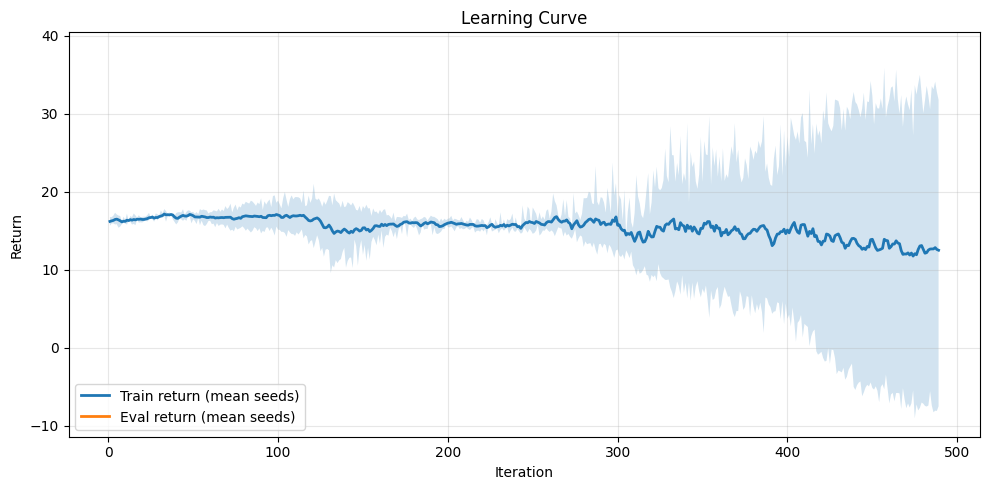

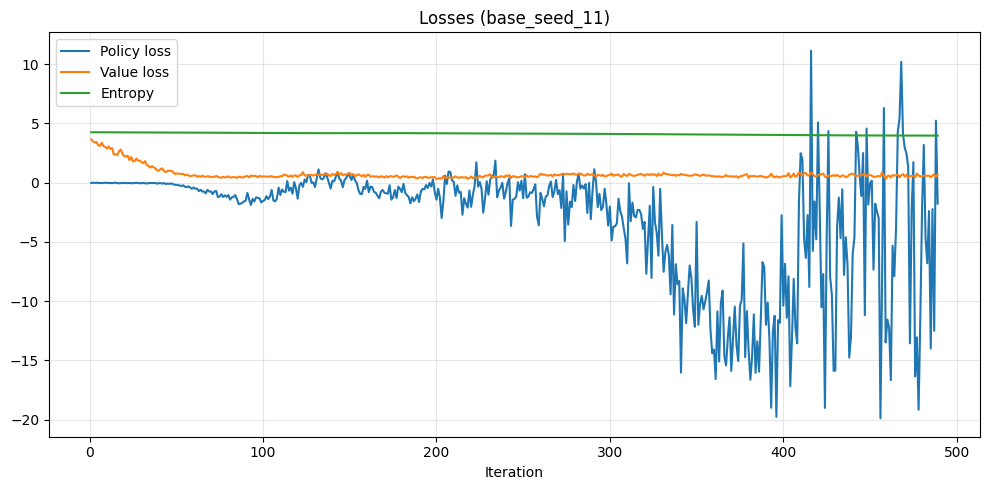

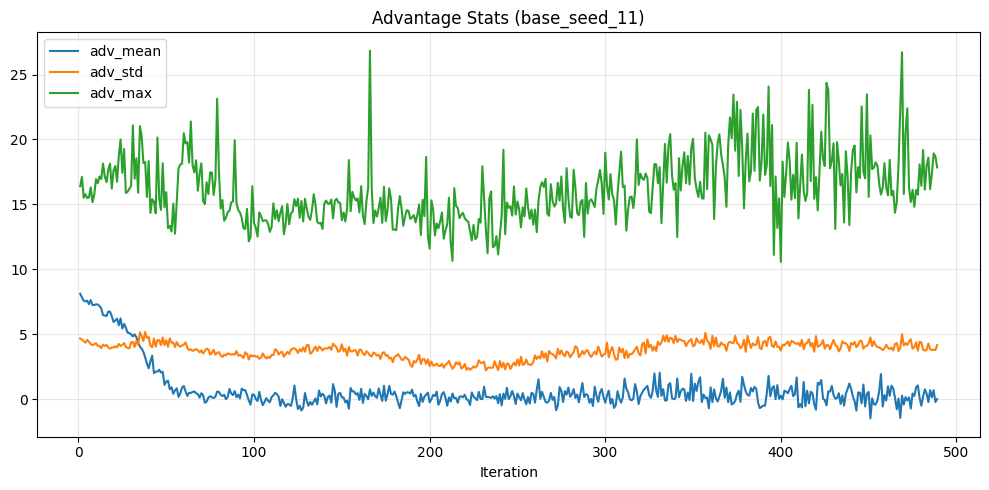

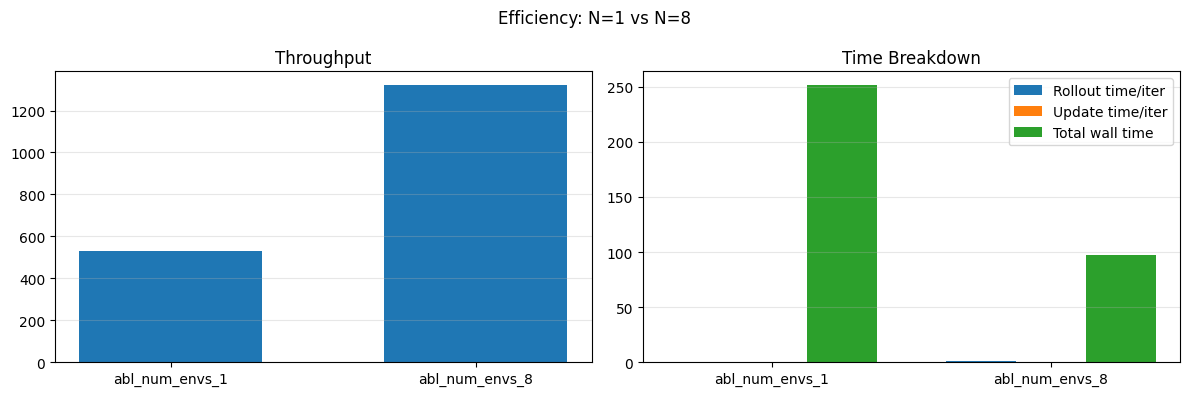

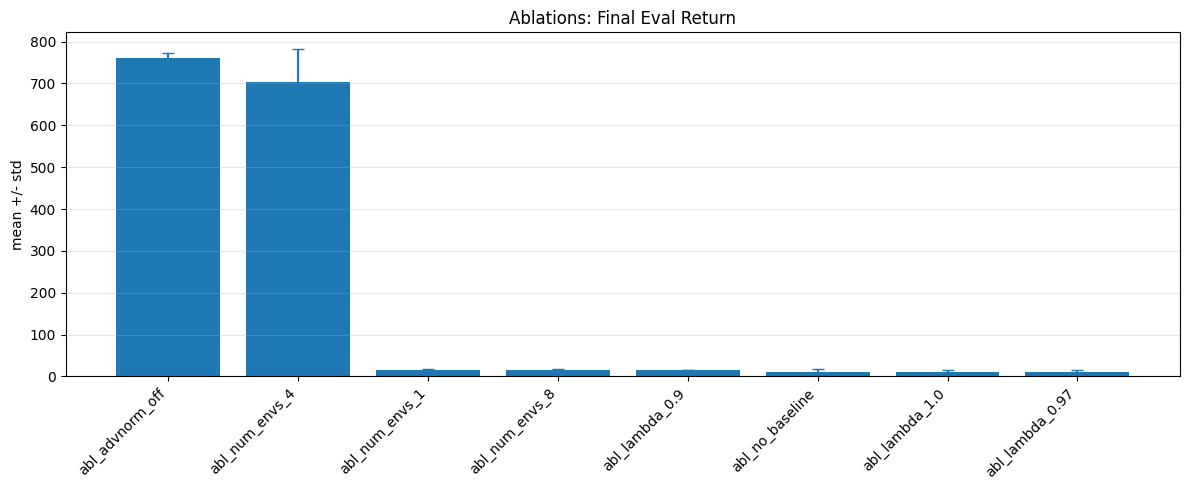

Saved figures:
- /content/runs/20260212_200221/learning_curve.png
- /content/runs/20260212_200221/losses.png
- /content/runs/20260212_200221/advantage_stats.png
- /content/runs/20260212_200221/efficiency.png
- /content/runs/20260212_200221/ablations_summary.png


In [14]:

def rmean(x,w=5): return x.rolling(w,min_periods=1).mean()

# learning_curve.png
p1=ROOT_RUN_DIR/'learning_curve.png'; plt.figure(figsize=(10,5))
base_keys=sorted([k for k in all_histories if k.startswith('base_seed_')])
if base_keys:
    md=[]
    for k in base_keys:
        d=all_histories[k][['iteration','train_episode_return_mean','eval_return_mean']].copy(); d['run']=k; md.append(d)
    md=pd.concat(md,ignore_index=True); it=sorted(md['iteration'].unique())
    trm=md.groupby('iteration')['train_episode_return_mean'].mean().reindex(it)
    trs=md.groupby('iteration')['train_episode_return_mean'].std().fillna(0).reindex(it)
    evm=md.groupby('iteration')['eval_return_mean'].mean().reindex(it)
    evs=md.groupby('iteration')['eval_return_mean'].std().fillna(0).reindex(it)
    plt.plot(it,rmean(trm,3),label='Train return (mean seeds)',lw=2); plt.fill_between(it,trm-trs,trm+trs,alpha=.2)
    plt.plot(it,evm,label='Eval return (mean seeds)',lw=2); plt.fill_between(it,evm-evs,evm+evs,alpha=.2)
plt.title('Learning Curve'); plt.xlabel('Iteration'); plt.ylabel('Return'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(p1,dpi=150); plt.show()

# losses.png
p2=ROOT_RUN_DIR/'losses.png'; plt.figure(figsize=(10,5))
if base_keys:
    d0=all_histories[base_keys[0]]
    plt.plot(d0['iteration'],d0['policy_loss'],label='Policy loss')
    plt.plot(d0['iteration'],d0['value_loss'],label='Value loss')
    plt.plot(d0['iteration'],d0['entropy'],label='Entropy')
plt.title(f'Losses ({base_keys[0] if base_keys else "N/A"})'); plt.xlabel('Iteration'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(p2,dpi=150); plt.show()

# advantage stats by iteration (required)
p_adv=ROOT_RUN_DIR/'advantage_stats.png'; plt.figure(figsize=(10,5))
if base_keys:
    d0=all_histories[base_keys[0]]
    plt.plot(d0['iteration'],d0['adv_mean'],label='adv_mean')
    plt.plot(d0['iteration'],d0['adv_std'],label='adv_std')
    plt.plot(d0['iteration'],d0['adv_max'],label='adv_max')
plt.title(f'Advantage Stats ({base_keys[0] if base_keys else "N/A"})')
plt.xlabel('Iteration'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.savefig(p_adv,dpi=150); plt.show()

# efficiency.png with speed + time breakdown
p3=ROOT_RUN_DIR/'efficiency.png'
ed=results_df[results_df['experiment_name'].isin(['abl_num_envs_1','abl_num_envs_8'])].copy()
fig,axs=plt.subplots(1,2,figsize=(12,4))
if not ed.empty:
    ed=ed.sort_values('num_envs')
    x=np.arange(len(ed)); labels=ed['experiment_name'].tolist(); w=0.25
    axs[0].bar(x,ed['mean_steps_per_sec'],width=0.6,label='Env steps/sec')
    axs[0].set_xticks(x); axs[0].set_xticklabels(labels)
    axs[0].set_title('Throughput')
    axs[0].grid(axis='y',alpha=.3)

    axs[1].bar(x-w,ed['mean_rollout_time_sec'],width=w,label='Rollout time/iter')
    axs[1].bar(x,ed['mean_update_time_sec'],width=w,label='Update time/iter')
    axs[1].bar(x+w,ed['total_wall_time_sec'],width=w,label='Total wall time')
    axs[1].set_xticks(x); axs[1].set_xticklabels(labels)
    axs[1].set_title('Time Breakdown')
    axs[1].grid(axis='y',alpha=.3)
    axs[1].legend()
else:
    axs[0].text(0.5,0.5,'No efficiency runs',ha='center',va='center')
    axs[1].text(0.5,0.5,'No efficiency runs',ha='center',va='center')

fig.suptitle('Efficiency: N=1 vs N=8')
fig.tight_layout(); fig.savefig(p3,dpi=150); plt.show()

# ablations_summary.png
p4=ROOT_RUN_DIR/'ablations_summary.png'; plt.figure(figsize=(12,5))
ap=results_df[~results_df['experiment_name'].str.startswith('base_seed_')].sort_values('final_eval_return_mean',ascending=False)
if not ap.empty:
    x=np.arange(len(ap)); plt.bar(x,ap['final_eval_return_mean'])
    plt.errorbar(x,ap['final_eval_return_mean'],yerr=ap['final_eval_return_std'],fmt='none',capsize=4)
    plt.xticks(x,ap['experiment_name'],rotation=45,ha='right')
plt.title('Ablations: Final Eval Return'); plt.ylabel('mean +/- std'); plt.grid(axis='y',alpha=.3); plt.tight_layout(); plt.savefig(p4,dpi=150); plt.show()

print('Saved figures:')
for p in [p1,p2,p_adv,p3,p4]:
    print('-',p)


**1) Learning behavior (Learning Curve)
The mean train return starts around 16–17 and gradually declines to 12–13 by the end.
Variance across base seeds grows strongly after 300 iterations (wide confidence band).
Interpretation: optimization is unstable over long horizon; different seeds diverge significantly.
2) Optimization signals (Losses: base_seed_11)
Policy loss becomes highly volatile after 300 iterations, with large negative spikes and occasional positive jumps.
Value loss drops early (good) then stays relatively low/stable (0.5–1 range).
Entropy is almost flat, indicating exploration pressure is not collapsing.
Interpretation: critic seems stable enough, but actor updates become noisy/unstable late in training.
3) Advantage dynamics (Advantage Stats: base_seed_11)
adv_mean quickly decays toward 0 and oscillates around zero later.
adv_std stays moderate (3–5), with gradual increase later.
adv_max increases and becomes spiky (up to 25+), indicating occasional high-advantage outliers.
Interpretation: advantage distribution gets heavier-tailed later, which likely amplifies policy-gradient variance.
4) Parallel efficiency (N=1 vs N=8)
Throughput increases from 530 steps/s (N=1) to ~1320 steps/s (N=8) => about 2.5x speedup.
Total wall-clock for equal-step efficiency run drops from 251s (N=1) to ~97s (N=8).
Update time/iter remains small; rollout collection dominates runtime.
Interpretation: vectorized envs provide clear practical speed gains in this setup.
5) Ablation summary (Final Eval Return)
Two runs dominate:
abl_advnorm_off 761
abl_num_envs_4 705
Most other runs remain low (10–16 range).
Interpretation: results are highly heterogeneous; top outcomes are likely sensitive to stochastic effects and need multi-seed confirmation before claiming robust superiority.
6) Consolidated conclusion
The notebook successfully demonstrates:
manual REINFORCE+GAE implementation,
parallel rollout collection,
metric logging and ablation workflow.
Main scientific finding from this run: high variance and seed sensitivity dominate performance conclusions.
Efficiency conclusions are reliable (N=8 faster), but quality conclusions require more seeds per ablation.**

In [15]:

summary_cols=['experiment_name','seed','final_eval_return_mean','final_eval_return_std','time_to_threshold_iter',
              'mean_steps_per_sec','mean_rollout_time_sec','mean_update_time_sec','total_wall_time_sec',
              'total_env_steps','num_envs','gae_lambda','use_baseline','normalize_advantage']
display(results_df[summary_cols].sort_values('experiment_name'))

base_res=results_df[results_df['experiment_name'].str.startswith('base_seed_')]
if not base_res.empty:
    print(f"Base stability over {len(base_res)} seeds: {base_res['final_eval_return_mean'].mean():.2f} +/- {base_res['final_eval_return_mean'].std(ddof=1):.2f}")
else:
    print('Base stability: no successful base runs')

from IPython.display import Markdown, display as dmd
if not results_df.empty:
    b=results_df.loc[results_df['final_eval_return_mean'].idxmax()]
    lines=[
        '### Data-driven Summary',
        f"- Best config: **{b['experiment_name']}**",
        f"- Final eval return: **{b['final_eval_return_mean']:.2f} +/- {b['final_eval_return_std']:.2f}**",
    ]
    nb_row=results_df[results_df['experiment_name']=='abl_no_baseline']
    if (not nb_row.empty) and (not base_res.empty):
        delta=base_res['final_eval_return_mean'].mean()-float(nb_row.iloc[0]['final_eval_return_mean'])
        lines.append(f"- Baseline effect (base mean - no baseline): **{delta:+.2f}**")
    lr=results_df[results_df['experiment_name'].str.startswith('abl_lambda_')]
    if not lr.empty:
        lb=lr.loc[lr['final_eval_return_mean'].idxmax()]
        lines.append(f"- Best lambda: **{lb['gae_lambda']}** (return={lb['final_eval_return_mean']:.2f})")
    er=results_df[results_df['experiment_name'].isin(['abl_num_envs_1','abl_num_envs_8'])]
    if len(er)==2:
        r1=er[er['experiment_name']=='abl_num_envs_1'].iloc[0]
        r8=er[er['experiment_name']=='abl_num_envs_8'].iloc[0]
        speed=r8['mean_steps_per_sec']/max(r1['mean_steps_per_sec'],1e-8)
        sample=r8['final_eval_return_mean']-r1['final_eval_return_mean']
        lines.append(f"- FPS speedup (N=8 vs N=1): **x{speed:.2f}**")
        lines.append(f"- Sample efficiency proxy (final eval delta N=8 - N=1): **{sample:+.2f}**")
    dmd(Markdown('\n'.join(lines)))


,experiment_name,seed,final_eval_return_mean,final_eval_return_std,time_to_threshold_iter,mean_steps_per_sec,mean_rollout_time_sec,mean_update_time_sec,total_wall_time_sec,total_env_steps,num_envs,gae_lambda,use_baseline,normalize_advantage
0,abl_advnorm_off,77,761.289806,11.102022,None,1335.624319,0.785239,0.012366,281.989179,250880,8,0.95,True,False
1,abl_lambda_0.9,55,16.003766,0.344844,None,1370.581185,0.761796,0.012418,191.684037,250880,8,0.90,True,True
2,abl_lambda_0.97,55,9.894288,4.517762,None,1360.624307,0.767671,0.012742,193.424005,250880,8,0.97,True,True
3,abl_lambda_1.0,55,10.144405,4.703122,None,1374.268178,0.759330,0.012636,192.639796,250880,8,1.00,True,True
4,abl_no_baseline,44,10.614066,8.119622,None,1406.686764,0.742308,0.004607,187.500035,250880,8,1.00,False,True
5,abl_num_envs_1,66,16.454218,0.558296,None,529.255902,0.244128,0.012018,251.517670,120064,1,0.95,True,True
6,abl_num_envs_4,66,704.737878,78.331406,None,1093.716125,0.475676,0.012442,142.286108,120320,4,0.95,True,True
7,abl_num_envs_8,66,16.262760,0.684610,None,1320.984779,0.795600,0.012627,97.177136,120832,8,0.95,True,True
8,base_seed_11,11,37.488247,8.518037,None,1363.419256,0.772585,0.014328,395.283835,500736,8,0.95,True,True
9,base_seed_22,22,16.122155,1.015400,None,1401.806376,0.744215,0.012560,374.423785,500736,8,0.95,True,True


Base stability over 3 seeds: 14.64 +/- 23.63


### Data-driven Summary
- Best config: **abl_advnorm_off**
- Final eval return: **761.29 +/- 11.10**
- Baseline effect (base mean - no baseline): **+4.02**
- Best lambda: **0.9** (return=16.00)
- FPS speedup (N=8 vs N=1): **x2.50**
- Sample efficiency proxy (final eval delta N=8 - N=1): **-0.19**